In [11]:
import pandas as pd
import numpy as np                   
import matplotlib.pyplot as plt      #
import seaborn as sns 
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [12]:
print(df.shape)
df.info()
df.describe()


(41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


10 númericas y 11 de texto

In [13]:
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Se comprueba que no hay ningun nulo
En este dataset no hay NaN sino unknown y en los pdays se usa 999 para representar aquellos que no se han contactado antes -->  Missing Attribute Values: There are several missing values in some categorical attributes, all coded with the "unknown" label.
A nivel de fila individual, no hay forma. default = "unknown" puede ser "el banco no tiene el dato" o "el cliente se negó a contestar", y el CSV no distingue. 


In [14]:
df['target'] = (df.y == 'yes').astype(int)
df.groupby('default').target.mean()

default
no         0.12879
unknown    0.05153
yes        0.00000
Name: target, dtype: float64

In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='str').columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'target']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [15]:
df['target'] = (df.y == 'yes').astype(int)

cats = df.select_dtypes(exclude='number').columns.drop('y')
for c in cats:
    print('===', c)
    print(df.groupby(c).target.agg(tasa='mean', n='size').sort_values('tasa', ascending=False).round(3))


=== job
                tasa      n
job                        
student        0.314    875
retired        0.252   1720
unemployed     0.142   1014
admin.         0.130  10422
management     0.112   2924
unknown        0.112    330
technician     0.108   6743
self-employed  0.105   1421
housemaid      0.100   1060
entrepreneur   0.085   1456
services       0.081   3969
blue-collar    0.069   9254
=== marital
           tasa      n
marital               
unknown   0.150     80
single    0.140  11568
divorced  0.103   4612
married   0.102  24928
=== education
                      tasa      n
education                        
illiterate           0.222     18
unknown              0.145   1731
university.degree    0.137  12168
professional.course  0.113   5243
high.school          0.108   9515
basic.4y             0.102   4176
basic.6y             0.082   2292
basic.9y             0.078   6045
=== default
          tasa      n
default              
no       0.129  32588
unknown  0.052   8

In [16]:
nums = df.select_dtypes('number').columns.drop('target')
df.groupby('target')[nums].mean().T.round(2)


target,0,1
age,39.91,40.91
duration,220.84,553.19
campaign,2.63,2.05
pdays,984.11,792.04
previous,0.13,0.49
emp.var.rate,0.25,-1.23
cons.price.idx,93.60,93.35
cons.conf.idx,-40.59,-39.79
euribor3m,3.81,2.12
nr.employed,5176.17,5095.12


El historial de contacto manda: quien ya participó en una campaña anterior contrata muchísimo más (65% si entonces aceptó, 14% si rechazó) frente al 8,8% de los clientes nuevos, y dentro de estos últimos la ocupación separa con claridad a estudiantes y jubilados (31% y 25%) de obreros y servicios (7-8%).

Lo demás apenas distingue estado civil, hipoteca, préstamo y día de la semana rondan todos la media del 11,3%, y conviene desconfiar de los grupos pequeños, donde un 15% aparente se apoya en apenas 80 casos.

In [24]:
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"{col:15} {n:6}  ({n / len(df) * 100:.1f}%)")


job                330  (0.8%)
marital             80  (0.2%)
education         1731  (4.2%)
default           8597  (20.9%)
housing            990  (2.4%)
loan               990  (2.4%)


In [25]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      99

In [26]:
print("Proporción con pdays=999:", (df['pdays'] == 999).mean())

print("\nDistribución de los que SÍ tienen historial:")
print(df.loc[df['pdays'] != 999, 'pdays'].describe())


Proporción con pdays=999: 0.9632174419733903

Distribución de los que SÍ tienen historial:
count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: pdays, dtype: float64


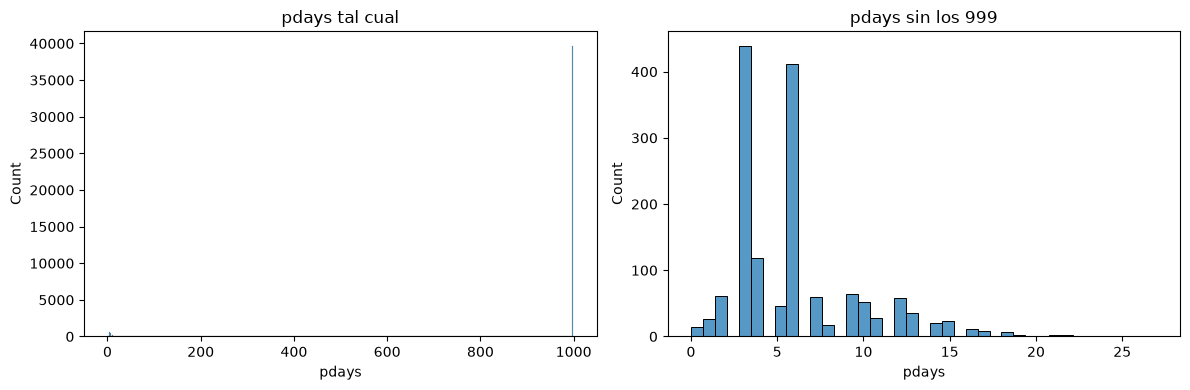

In [27]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
sns.histplot(df['pdays'], ax=axes[0])
axes[0].set_title('pdays tal cual')
sns.histplot(df.loc[df['pdays'] != 999, 'pdays'], ax=axes[1])
axes[1].set_title('pdays sin los 999')
plt.tight_layout()
plt.show()


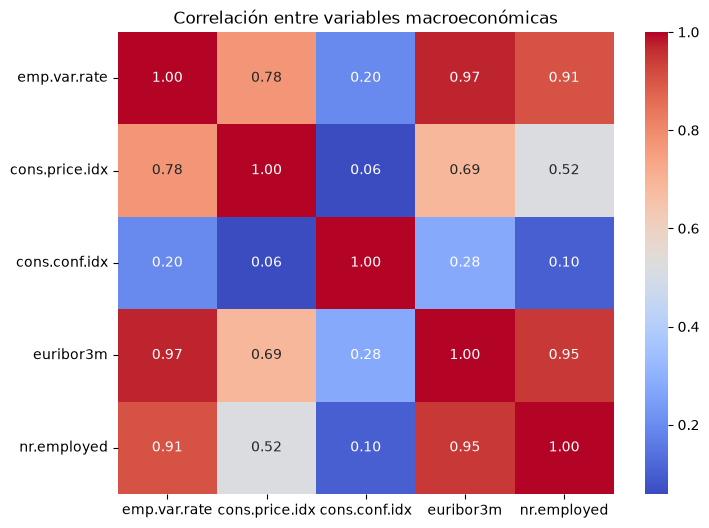

In [28]:
macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(8, 6))
sns.heatmap(df[macro].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables macroeconómicas')
plt.show()


	emp.var	euribor3m	nr.employed
emp.var.rate	1.00	0.97	0.91
euribor3m	0.97	1.00	0.95
nr.employed	0.91	0.95	1.00

In [ ]:
# duration: no se conoce ANTES de hacer la llamada -> fuga de datos (data leakage)
# y: ya esta recogida en 'target'
df = df.drop(columns=['duration', 'y'], errors='ignore')
print(df.shape)

In [ ]:
if 'pdays' in df.columns:
    df['contactado_antes'] = (df['pdays'] != 999).astype(int)
    df = df.drop(columns=['pdays'])

print(df.groupby('contactado_antes').target.agg(tasa='mean', n='size').round(3))

In [ ]:
df = df.drop(columns=['emp.var.rate', 'nr.employed'], errors='ignore')
print(df.shape)
df.head()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ('target', 'contactado_antes')]
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(len(num_cols), 'numericas: ', num_cols)
print(len(cat_cols), 'categoricas:', cat_cols)

---
# FASE 6 - Dummies, split y escalado

**Orden correcto: dummies -> split -> escalado.**

El escalado va **despues** del split y se ajusta **solo con train**. Si se escala el
DataFrame entero antes de partir, la media y la desviacion se calculan usando tambien
las filas de test: eso es *data leakage* y el test deja de ser "datos nunca vistos".

In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df.shape)
df.head()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print('Proporcion de si -> train:', round(y_train.mean(), 4), '| test:', round(y_test.mean(), 4))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])   # el scaler APRENDE solo de train
X_test[num_cols]  = scaler.transform(X_test[num_cols])        # transform, NO fit_transform

X_train[num_cols].head()

---
# FASE 7 - Modelo base

`class_weight='balanced'` penaliza los errores en la clase minoritaria proporcionalmente
a su rareza (~8x aqui). Sin el, el recall de la clase 1 cae a ~0.20.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

pred  = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print('AUC:', round(roc_auc_score(y_test, probs), 4))

## Coeficientes

Ya se quitaron las macro redundantes, asi que los coeficientes son interpretables.
Positivo = aumenta la probabilidad de contratar.

In [ ]:
coefs = pd.Series(model.coef_[0], index=X_train.columns).sort_values()

fig, axes = plt.subplots(ncols=2, figsize=(14, 5))
coefs.tail(10).plot.barh(ax=axes[0], color='green')
axes[0].set_title('Top 10 a favor de contratar')
coefs.head(10).plot.barh(ax=axes[1], color='red')
axes[1].set_title('Top 10 en contra')
plt.tight_layout()
plt.show()

---
# FASE 8 - Evaluacion

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistica (AUC = {roc_auc_score(y_test, probs):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Separacion de las dos clases segun la probabilidad asignada
plt.figure(figsize=(8, 5))
sns.kdeplot(probs[y_test == 0], label='No contrata', fill=True, color='red')
sns.kdeplot(probs[y_test == 1], label='Contrata',   fill=True, color='green')
plt.title(f'Separacion de clientes (AUC: {roc_auc_score(y_test, probs):.3f})')
plt.xlabel('Probabilidad asignada por el modelo')
plt.legend()
plt.show()

## Analisis del umbral

El 0.5 por defecto es una convencion, no una ley. Bajarlo capta mas clientes (sube el
recall) a costa de mas llamadas en balde (sube el FPR). **Aqui esta la palanca de negocio.**

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

umbrales = np.linspace(0.05, 0.95, 100)
acc, tpr_l, fpr_l, prec = [], [], [], []

for t in umbrales:
    yp = (probs >= t).astype(int)
    acc.append(accuracy_score(y_test, yp))
    tpr_l.append(recall_score(y_test, yp))
    prec.append(precision_score(y_test, yp, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    fpr_l.append(fp / (fp + tn))

plt.figure(figsize=(9, 5))
plt.plot(umbrales, acc,   label='Accuracy',           color='blue',   lw=2)
plt.plot(umbrales, tpr_l, label='Recall (captura)',   color='green',  lw=2)
plt.plot(umbrales, prec,  label='Precision',          color='orange', lw=2)
plt.plot(umbrales, fpr_l, label='FPR (falsa alarma)', color='red',    lw=2, ls='--')
plt.axvline(0.5, color='gray', ls=':', label='Umbral estandar')
plt.xlabel('Umbral de probabilidad')
plt.ylabel('Score / Tasa')
plt.title('Metricas segun el umbral')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Traduccion a negocio: cuantas llamadas hay que hacer y cuantos clientes se captan
filas = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yp = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    filas.append({
        'umbral':            t,
        'llamadas':          tp + fp,
        'contratos':         tp,
        'clientes perdidos': fn,
        '% de acierto':      round(tp / (tp + fp), 3),
        'recall':            round(tp / (tp + fn), 3),
    })

pd.DataFrame(filas)

---
# FASE 9 - Comparativa de modelos

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos = {
    'Logistica':     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Arbol':         DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5,
                                            class_weight='balanced', random_state=42),
}

resultados = []
for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    p = mod.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, mod.predict(X_test), output_dict=True)
    resultados.append({
        'Modelo':    nombre,
        'AUC':       round(roc_auc_score(y_test, p), 4),
        'Accuracy':  round(rep['accuracy'], 4),
        'Precision': round(rep['1']['precision'], 4),
        'Recall':    round(rep['1']['recall'], 4),
        'F1':        round(rep['1']['f1-score'], 4),
    })

pd.DataFrame(resultados).sort_values('AUC', ascending=False)

In [ ]:
# Las tres curvas ROC superpuestas
plt.figure(figsize=(7, 5))
for nombre, mod in modelos.items():
    p = mod.predict_proba(X_test)[:, 1]
    f, t, _ = roc_curve(y_test, p)
    plt.plot(f, t, label=f'{nombre} (AUC = {roc_auc_score(y_test, p):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparativa de curvas ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
imp = pd.Series(modelos['Random Forest'].feature_importances_, index=X_train.columns)

plt.figure(figsize=(8, 6))
imp.sort_values(ascending=False).head(15).sort_values().plot.barh()
plt.title('Importancia de variables (Random Forest)')
plt.tight_layout()
plt.show()

---
# FASE 10 - Optimizacion (GridSearchCV)

`scoring='roc_auc'` en vez de `recall`: con `class_weight='balanced'` el recall ya es alto,
y optimizar solo recall premia a un modelo que diga "si" a todo. El AUC mide la capacidad
de **ordenar** clientes por probabilidad, que es lo que de verdad usa el call center.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, 20],
    'min_samples_leaf': [1, 20],
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3,
                    scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Mejores parametros:', grid.best_params_)
print('Mejor AUC en CV   :', round(grid.best_score_, 4))

In [ ]:
best_rf = grid.best_estimator_
probs_best = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_rf.predict(X_test)))
print('AUC en test:', round(roc_auc_score(y_test, probs_best), 4))

---
# EXPERIMENTO - El coste del leakage

Se repite todo el pipeline **incluyendo `duration`** para ver el AUC inflado.

`duration` solo se conoce **despues** de la llamada, asi que un modelo que la use no se
puede desplegar: el dia que haya que decidir a quien llamar, ese dato no existe.

In [ ]:
def pipeline(con_duration):
    d = pd.read_csv('../data/bank-additional-full.csv', sep=';')
    d['target'] = (d.y == 'yes').astype(int)
    d = d.drop(columns=['y', 'emp.var.rate', 'nr.employed'])
    d['contactado_antes'] = (d['pdays'] != 999).astype(int)
    d = d.drop(columns=['pdays'])
    if not con_duration:
        d = d.drop(columns=['duration'])

    n = [c for c in d.select_dtypes(include=np.number).columns
         if c not in ('target', 'contactado_antes')]
    c = d.select_dtypes(exclude=np.number).columns.tolist()
    d = pd.get_dummies(d, columns=c, drop_first=True)

    Xa, ya = d.drop(columns='target'), d['target']
    Xtr, Xte, ytr, yte = train_test_split(Xa, ya, test_size=0.3,
                                          random_state=42, stratify=ya)
    sc = StandardScaler()
    Xtr[n] = sc.fit_transform(Xtr[n])
    Xte[n] = sc.transform(Xte[n])

    m = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    m.fit(Xtr, ytr)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

auc_con = pipeline(True)
auc_sin = pipeline(False)

print(f'AUC CON duration (leakage) : {auc_con:.4f}')
print(f'AUC SIN duration (real)    : {auc_sin:.4f}')
print(f'Inflado artificialmente en : {auc_con - auc_sin:.4f}')

## Conclusiones

1. **El accuracy no vale aqui.** Un modelo que diga "no" siempre acierta el 88.7%.
   Las metricas utiles son el AUC y el recall de la clase 1.
2. **`class_weight='balanced'` es lo que mas mueve la aguja**: sube el recall de ~0.20 a ~0.65.
3. **El contexto economico manda sobre el perfil del cliente.** `euribor3m` pesa mas
   que la edad o la profesion: se esta modelando la crisis de 2008, no al cliente.
4. **El historial de contacto es la mejor variable de campania**: 64% de contratacion
   entre los ya contactados frente al 9% entre los nuevos.
5. **El umbral es una decision de negocio, no estadistica.** Depende de cuanto cuesta
   una llamada frente a lo que deja un deposito.